# Tu primera red neuronal: clasificación en FashionMNIST

En este notebook construimos un pipeline completo de clasificación de imágenes:
1. Cargar y explorar el dataset **FashionMNIST**
2. Preprocesar los datos (normalización)
3. Definir una red neuronal feedforward
4. Entrenarla
5. Evaluar resultados
6. Guardar y cargar el modelo
7. Usar el modelo para predicciones

**¿Por qué FashionMNIST?** Tiene el mismo formato que MNIST (imágenes en escala de grises de 28×28, 10 clases) pero es más difícil — clasifica prendas de ropa en lugar de dígitos escritos a mano. Esto lo hace más realista mientras mantiene el pipeline simple.

## El dataset FashionMNIST

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Usamos valores precalculados para FashionMNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)

print(f"Conjunto de entrenamiento: {len(train_dataset)} muestras")
print(f"Conjunto de prueba:        {len(test_dataset)} muestras")
print(f"Forma de la imagen: {train_dataset[0][0].shape}")
print(f"Clases: {train_dataset.classes}")

Conjunto de entrenamiento: 60000 muestras
Conjunto de prueba:        10000 muestras
Forma de la imagen: torch.Size([1, 28, 28])
Clases: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### ¿Por qué codificamos la Media y la Desviación Estándar?

Las redes neuronales entrenan de forma más eficiente cuando los valores de entrada están centrados en cero con varianza pequeña. Aunque `ToTensor()` escala los valores de píxel de `[0, 255]` a `[0.0, 1.0]`, usamos `Normalize()` para desplazar ese rango a aproximadamente `[-1.0, 1.0]`.

Para datasets masivos, calcular la media y la desviación estándar exactas requiere iterar sobre todo el dataset fuera de memoria (cargando pequeños Batches a la vez). Para simplificar el paso de preprocesamiento y evitar esta sobrecarga computacional cada vez que ejecutamos el script, es práctica estándar usar **valores codificados**:

- **Normalización Perezosa/Simétrica (p. ej., `mean=0.5, std=0.5`)**: Un atajo matemático que fuerza el rango `[0.0, 1.0]` exactamente a `[-1.0, 1.0]`.
- **Estadísticas Precalculadas del Dataset**: Usar los promedios matemáticos conocidos del dataset (p. ej., MNIST tiene media `0.1307` y desviación estándar `0.3081`).

En este notebook, omitimos el cálculo manual y usamos directamente los valores estándar codificados.

## Exploración de los datos

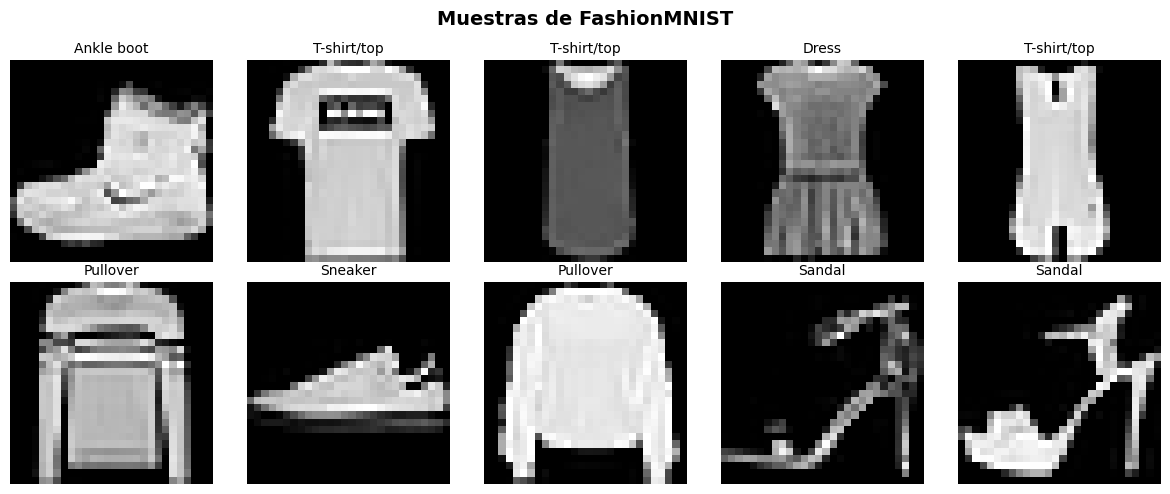

In [3]:
# Nombres de clases para etiquetas legibles
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Visualizar una cuadrícula de muestras
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label], fontsize=10)
    ax.axis("off")
fig.suptitle("Muestras de FashionMNIST", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Preprocesamiento de datos

## DataLoaders

`DataLoader` gestiona el agrupado en Batches y la mezcla aleatoria. Mezclamos los datos de entrenamiento (para evitar aprender el orden) pero no los de prueba:

In [4]:
BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
)

# Verificar un Batch
images, labels = next(iter(train_loader))
print(f"Forma del Batch: {images.shape}")   # (64, 1, 28, 28)
print(f"Forma de etiquetas: {labels.shape}")  # (64,)

Forma del Batch: torch.Size([64, 1, 28, 28])
Forma de etiquetas: torch.Size([64])


## Definiendo la red neuronal

Nuestra red toma imágenes de 28×28 píxeles (aplanadas a 784 valores) y las clasifica en 10 categorías.

Arquitectura: `Flatten → Linear(784, 512) → ReLU → Dropout → Linear(512, 256) → ReLU → Dropout → Linear(256, 10)`

**¿Qué hacen estas capas?**
- **Flatten**: reforma la imagen 2D en un vector 1D.
- **Linear**: capa totalmente conectada (multiplicación de matrices + Bias).
- **ReLU**: Activation no lineal (conserva los positivos, pone a cero los negativos).
- **Dropout**: Desactiva aleatoriamente un porcentaje de neuronas (20% en este caso) durante cada paso de entrenamiento para prevenir el Overfitting. Aunque parece que se pierde información, en realidad obliga a la red a aprender representaciones redundantes y robustas en lugar de simplemente memorizar muestras del entrenamiento.

**¿Por qué esta arquitectura en particular?**
- **Tamaños de capa decrecientes (512 → 256 → 10)**: Creamos un cuello de botella de información, comprimiendo gradualmente los 784 píxeles brutos en características de más alto nivel antes de tomar la decisión final de 10 clases.
- **Activations ReLU**: Una Activation Function estándar y efectiva que permite a la red aprender patrones no lineales sin sufrir de gradientes evanescentes.
- **Dropout (p=0.2)**: Con más de 500K parámetros para solo 60K imágenes de entrenamiento, la red tiende a memorizar el conjunto de entrenamiento (Overfitting). Eliminar el 20% de las neuronas actúa como regularización, forzando a la red a aprender representaciones más robustas y distribuidas.

**Pregunta frecuente: ¿Cómo sé qué arquitectura definir?**
No existe una "fórmula mágica" para diseñar redes neuronales, pero hay buenas prácticas establecidas:
1. **Las dimensiones de entrada/salida son fijas**: La primera capa debe coincidir con tus datos (784 para una imagen 28x28) y la última con tu tarea (10 para 10 clases).
2. **Las Hidden Layers son empíricas**: Una heurística común es usar potencias decrecientes de 2 (p. ej., 512 → 256) para condensar la información gradualmente.
3. **Empieza simple, luego escala**: Comienza con una arquitectura sencilla (p. ej., 1 o 2 Hidden Layers). Si tiene Underfitting (bajo rendimiento en datos de entrenamiento), hazla más profunda o ancha. Si tiene Overfitting (buena en entrenamiento, mala en prueba), agrega Dropout o reduce el tamaño del modelo.
4. **Copia lo que funciona**: Para clasificación de imágenes, los practicantes raramente construyen redes desde cero hoy en día; usan arquitecturas probadas como ResNet o EfficientNet.

In [5]:
import torch.nn as nn

class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.flatten(x)
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FashionClassifier().to(device)
print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")

FashionClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total de parámetros: 535,818


## Loss Function y Optimizer

- **CrossEntropyLoss**: Loss estándar para clasificación multiclase. Espera logits brutos (no se necesita Softmax — la Loss Function lo aplica internamente para estabilidad numérica).
- **Adam**: Optimizer adaptivo que ajusta el Learning Rate por parámetro. Una elección robusta por defecto.

In [6]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## Ciclo de entrenamiento

In [7]:
def train_one_epoch(model: nn.Module, loader, loss_fn, optimizer, device) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        predictions = model(images)
        loss = loss_fn(predictions, labels)

        # Backward pass + actualización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model: nn.Module, loader, loss_fn, device) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        predictions = model(images)
        loss = loss_fn(predictions, labels)

        total_loss += loss.item() * images.size(0)
        correct += (predictions.argmax(dim=1) == labels).sum().item()
        total += images.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [8]:
NUM_EPOCHS = 10

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, loss_fn, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Epoch {epoch:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Test  Loss: {test_loss:.4f}  Acc: {test_acc:.4f}"
    )

Epoch  1/10 | Train Loss: 0.4845  Acc: 0.8204 | Test  Loss: 0.4098  Acc: 0.8523
Epoch  2/10 | Train Loss: 0.3741  Acc: 0.8625 | Test  Loss: 0.3648  Acc: 0.8691
Epoch  3/10 | Train Loss: 0.3421  Acc: 0.8740 | Test  Loss: 0.3627  Acc: 0.8671
Epoch  4/10 | Train Loss: 0.3210  Acc: 0.8811 | Test  Loss: 0.3361  Acc: 0.8768
Epoch  5/10 | Train Loss: 0.3065  Acc: 0.8863 | Test  Loss: 0.3365  Acc: 0.8769
Epoch  6/10 | Train Loss: 0.2912  Acc: 0.8905 | Test  Loss: 0.3550  Acc: 0.8742
Epoch  7/10 | Train Loss: 0.2808  Acc: 0.8943 | Test  Loss: 0.3310  Acc: 0.8839
Epoch  8/10 | Train Loss: 0.2726  Acc: 0.8978 | Test  Loss: 0.3203  Acc: 0.8842
Epoch  9/10 | Train Loss: 0.2645  Acc: 0.8995 | Test  Loss: 0.3343  Acc: 0.8801
Epoch 10/10 | Train Loss: 0.2546  Acc: 0.9038 | Test  Loss: 0.3466  Acc: 0.8755


## Análisis de resultados

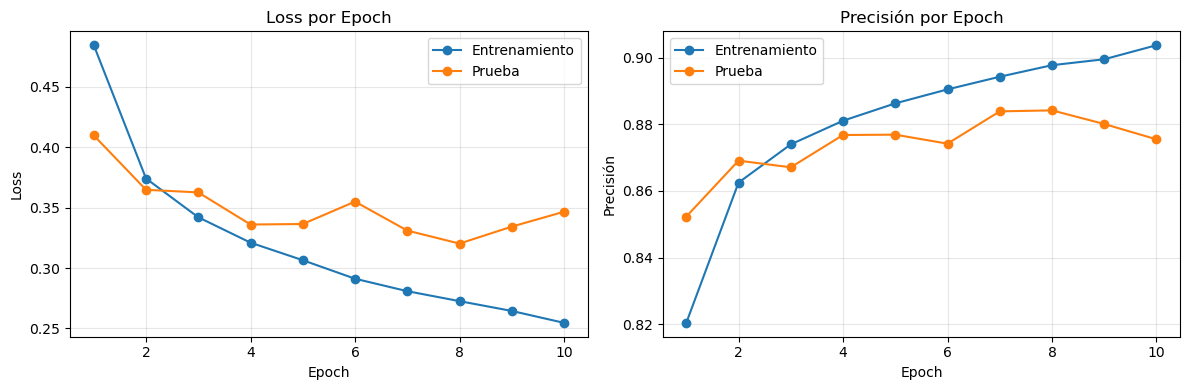

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_EPOCHS + 1)

# Curvas de Loss
ax1.plot(epochs, history["train_loss"], "o-", label="Entrenamiento")
ax1.plot(epochs, history["test_loss"], "o-", label="Prueba")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss por Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Curvas de precisión
ax2.plot(epochs, history["train_acc"], "o-", label="Entrenamiento")
ax2.plot(epochs, history["test_acc"], "o-", label="Prueba")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Precisión")
ax2.set_title("Precisión por Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Veamos predicciones específicas — tanto correctas como incorrectas:

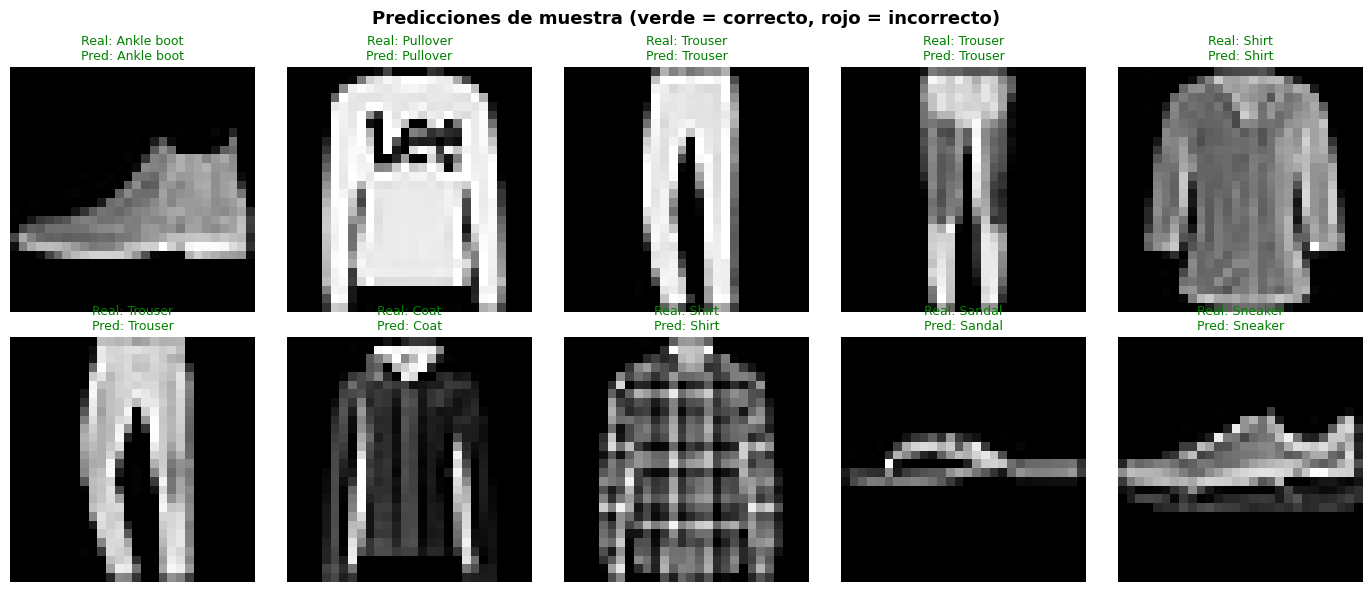

In [10]:
# Mostrar predicciones en un Batch de imágenes de prueba
model.eval()
test_images, test_labels = next(iter(test_loader))
test_images, test_labels = test_images.to(device), test_labels.to(device)

with torch.no_grad():
    logits = model(test_images)
    predicted = logits.argmax(dim=1)

# Mostrar las primeras 10 predicciones
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = test_images[i].cpu().squeeze()
    true_label = class_names[test_labels[i]]
    pred_label = class_names[predicted[i]]
    correct = true_label == pred_label

    ax.imshow(img, cmap="gray")
    color = "green" if correct else "red"
    ax.set_title(f"Real: {true_label}\nPred: {pred_label}", fontsize=9, color=color)
    ax.axis("off")

fig.suptitle("Predicciones de muestra (verde = correcto, rojo = incorrecto)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Guardar y cargar el modelo

PyTorch recomienda guardar solo el **state dict** (los parámetros aprendidos), no el objeto del modelo completo. Esto es más robusto ante cambios en el código:

In [11]:
# Guardar
torch.save(model.state_dict(), "fashionmnist_model.pth")
print("Modelo guardado en fashionmnist_model.pth")

# Cargar (primero debes definir la arquitectura del modelo)
loaded_model = FashionClassifier().to(device)
loaded_model.load_state_dict(torch.load("fashionmnist_model.pth", weights_only=True))
loaded_model.eval()

# Verificar que funciona
test_loss, test_acc = evaluate(loaded_model, test_loader, loss_fn, device)
print(f"Modelo cargado — Precisión en prueba: {test_acc:.4f}")

Modelo guardado en fashionmnist_model.pth
Modelo cargado — Precisión en prueba: 0.8755


## Uso del modelo para predicciones

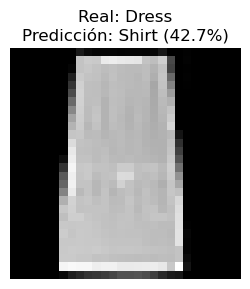

In [14]:
@torch.no_grad()
def predict(model: nn.Module, image: torch.Tensor, device) -> tuple[str, float]:
    """Predice la clase de una sola imagen."""
    model.eval()
    image = image.unsqueeze(0).to(device)  # Agregar dimensión de Batch
    logits = model(image)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()
    return class_names[predicted_class], confidence

# Predecir en una imagen de prueba aleatoria
idx = 42
image, true_label = test_dataset[idx]
pred_label, confidence = predict(model, image, device)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(image.squeeze(), cmap="gray")
ax.set_title(f"Real: {class_names[true_label]}\nPredicción: {pred_label} ({confidence:.1%})")
ax.axis("off")
plt.show()

> **Nota:** si quieres experimentar con datos más fáciles, cambia `FashionMNIST` por `MNIST` en las celdas de carga del dataset. El resto del código funciona sin cambios — MNIST usa el mismo formato de 28×28 en escala de grises con 10 clases (dígitos del 0 al 9). Deberías ver mayor precisión (~97%+) ya que los dígitos son más simples de clasificar que las prendas de ropa.